# Практическое ДЗ-2. Использование ALS для построения рекомендательной модели

В этой задаче мы построим простую рекомендательную модель на основе малоранговых приближений.

In [5]:
import numpy as np
import scipy.sparse
import matplotlib.pyplot as plt
%matplotlib inline

### Подготовка датасета
Загрузите датасет movielens10m с [grouplens.org](https://grouplens.org/datasets/movielens/10m/) или [disk.yandex.ru](https://disk.yandex.ru/d/HIjLehGZEcCRig) и положите архив в папку `data`. Нас будет интересовать файл `ratings.dat`, в котором собраны оценки пользователями различных фильмов с сервиса movielens.org. Вытащим этот файл из архива. Как можно узнать из соответствующей [странички](http://files.grouplens.org/datasets/movielens/ml-10m-README.html#file_desc), этот файл имеет формат `UserID::MovieID::Rating::Timestamp`. Сразу позаботимся, чтобы id пользователей и фильмов начинались с нуля (в самом файле индексация с единицы).

In [6]:
import zipfile
user_ids = []
movie_ids = []
ratings = []
with zipfile.ZipFile('data/ml-10m.zip') as archive:
    with archive.open('ml-10M100K/ratings.dat') as f:
        for l in f:
            user, movie, rating, _ = l.split(b'::')
            user_ids.append(int(user) - 1)
            movie_ids.append(int(movie) - 1)
            ratings.append(float(rating))

Составим матрицу рейтингов $A \in \mathbb R^{m \times n}$, индексируемую номером пользователем и номером фильма.
Для простоты мы будем делить отзывы только на положительные (`Rating >= 4` &mdash; $A_{i,j}=1$) и отрицательные (`Rating < 4` &mdash; $A_{i,j} = 0$), таким образом, матрица у нас получится состоящей только из нулей и единиц.
Обратите внимание, что матрица будет разреженной, так как средний пользователь оценил относительно мало фильмов. Поэтому мы будем пользоваться библиотекой `scipy.sparse`. Хранить матрицу мы будем в формате хранения разреженных матриц [CSR](https://en.wikipedia.org/wiki/Sparse_matrix#Compressed_sparse_row_(CSR,_CRS_or_Yale_format)), который поддерживает матричное умножение на numpy массивы: ```A @ X ```.

In [7]:
from scipy.sparse import csr_matrix
A = csr_matrix((np.array(ratings) >= 4, (user_ids, movie_ids)), dtype=np.float32)
A.eliminate_zeros()
print("Shape:", A.shape)
print("Ratio of nonzero elements:", A.nnz / (A.shape[0] * A.shape[1]))

Shape: (71567, 65133)
Ratio of nonzero elements: 0.0010738646228571796


Отделим некоторое количество пользователей для последующей проверки. Используем стандартное разбиение train/test 80/20.

In [8]:
n_users, n_movies = A.shape
n_test = int(n_users * 0.2)
n_train = n_users - n_test
idx = np.arange(n_users)
np.random.shuffle(idx)
test_idx, train_idx = idx[:n_test], idx[n_test:]
A_test, A_train = A[test_idx,:], A[train_idx,:]

Далее в задаче мы будем строить рекомендации пользователям на основе малорангового приближения матрицы $A$ (матрицы $A_{train}$ в рамках обозначений выше).
Обратим внимание, что из-за ограничений по памяти мы не можем сформировать матрицу $A$ в виде numpy массива, а значит теряем доступ к ```np.linalg.svd```. Поэтому мы будем реализовывать метод ALS, в котором требуется только умножение на матрицы $A$ и $A^\top$, что поддерживается разреженными форматами хранения матриц (CSR, COO и тд).

### a. (35 баллов) Вычисление вспомогательных функционалов

  1. **(15 баллов)** Напомним, что в методе ALS решается задача минимизации функционала $f(U, V^\top) = \|A - UV^\top\|_F$ по всем $U \in \mathbb R^{m \times r}$ и $V  \in \mathbb R^{n \times r}$. Первым делом вам нужно будет написать функцию `als_functional` для вычисления оптимизируемого функционала $\|A - UV^\top\|_F$ для заданных $A$, $U$, $V^\top$. Заметьте, что прямое вычисление этой нормы &mdash; очень трудоёмкая задача, ведь разность будет плотной матрицей. Для того, чтобы эффективно вычислить норму разности, распишите $\|A - UV^\top\|_F^2$ через скалярное произведение $\langle X,Y \rangle_F = \mathrm{Tr}\,(X^\top Y)$, выполните алгебраические преобразования и покажите, как эффективно вычислить каждый член в полученном выражении. Имеется в виду, что ни на каком этапе вы не должны явно формировать плотные матрицы размеров `A.shape` (хотя numpy, скорее всего, и откажется аллоцировать 37 ГБ под такой массив).
  
  **Замечание**: не используйте циклы по ненулевым элементам разреженной матрицы $A$. Убедитесь, что в ваши формулы входит только умножение на матрицы $A$ или $A^\top$, на которые можно умножать посредством @; либо умножения сложности $O(mr^2), O(nr^2)$. Также отметим, что норма матрицы $A$ уже дана, заново её вычислять не надо. Везде считайте $r < m, n$.

In [9]:
def als_functional(A, A_norm, U, VT):
    """
        Input
            A: sparse 2D array
            A_norm: Frobenius norm of A
            U, VT: 2D arrays such that U @ VT approximates A
        Output
            ||A - U VT||_F
    """
    UTU = U.T @ U
    VTV = VT @ VT.T
    norm2 = (UTU @ VTV).trace()
    norm3 = 2 * (U.T @ A @ VT.T).trace()
    return np.sqrt(A_norm ** 2 + norm2 - norm3)

**Замечание:** Если вы не сможете выполнить следующие два пункта, можете их пропустить. Они не являются обязательными для следующих заданий.

  2. **(10 баллов)** Ещё одной метрикой сходимости ALS-процесса, помимо стабилизации самого функционала, может служить так называемое расстояние между подпространствами. Расстоянием между подпространствами $L_1 \subset \mathbb{R}^m$ и $L_2 \subset \mathbb{R}^m$ будем называть число $\|P(L_1) - P(L_2)\|_2$, где $P(L_i)$ &mdash; ортопроектор на $L_i$. Опишите алгоритм вычисления расстояния между двумя подпространствами $\mathrm{Im}(U_1)$ и $\mathrm{Im}(U_2)$ для заданных матриц $U_1, U_2 \in \mathbb{R}^{m \times r}$ с ортонормированными столбцами (т.е. $U_i^T U_i = I$). Алгоритм должен иметь сложность $O(mr^2)$. **Подсказка.** Воспользуйтесь фактом, что ортопроекторы являются матрицами малого ранга $r$, и техникой малоранговой арифметики, описанной на соответствующих лекции и семинаре.

Так как $U_i = U_i\Sigma_r\Sigma_r$, то $P(U_i) = U_iU_i^T$. Обозначим $P_i = U_iU_i^T$. То есть нам надо найти $\|P_1 - P_2\|_2 = \|U_1U_1^T - U_2U_2^T\|_2$. Обозначим $A = P_1-P_2$. Сразу отметим, что $U_1U_1^T - U_2U_2^T$ - симметричная матрица $\Rightarrow$ её сингулярные значения совпадают с модулями собственных значений. [Proof](https://rampure.org/resources/data100/notes/eigen-singular.html)

Рассмотрим полное SVD $U_1^TU_2 = Q_1\Sigma Q_2^T$. Рассмотрим $V_i = U_iQ_i$. Тогда

$$V_1^TV_2 = Q_1^TU_1^TU_2Q_2 = \underbrace{Q_1^TQ_1}_{=I}\Sigma \underbrace{Q_2^T Q_2}_{=I} = \Sigma$$

$$V_iV_i^T = U_i\underbrace{Q_iQ_i^T}_{=I}U_i^T = U_iU_i^T = P_i$$

$$V_i^TV_i = Q_i^T\underbrace{U_i^TU_i}_{=I}Q_i = Q_i^TQ_i = I$$

Тогда $\|P_1 - P_2\|_2 = \|V_1V_1^T - V_2V_2^T\|_2$, где $V_i$ с ортнормированными столбцами и $\langle v_{1,i}, v_{2,j}\rangle = \begin{cases}
0 & \text{, } i \ne j \\
\sigma_i & \text{, } i = j
\end{cases}$

Рассмотрим $W = span(V_1, V_2)$. Если $v \in W^{\perp}$, то $U_1^Tv = 0$ и $U_2^Tv = 0$

$$U_1\underbrace{U_1^Tv}_{=0} - U_2\underbrace{U_2^Tv}_{=0} = (P_1-P_2)v = 0$$

Заметим, что $W = \bigoplus\limits_{i=1}\limits^{r} W_i$, где $W_i = span (v_{1,i}, v_{2,i})$. Действительно, так как если $i \ne j$, то скалярные произведения $\{v_{1,i}, v_{2,i}\}$ и $\{v_{1,j}, v_{2, j}\}$ равны 0.

Покажем, что $W_i$ инварианта относительно $A$.

$$Av_{1,i} = V_1(V_1^Tv_{1,i}) - V_2(V_2^Tv_{1,i}) = V_1\cdot e_i - V_2 \cdot \sigma_i e_i = v_{1,i} - \sigma_{i}v_{2,i} \in W_i$$

$$Av_{2,i} = V_1(V_1^Tv_{2,i}) - V_2(V_2^Tv_{2,i}) = V_1\cdot \sigma_i e_i - V_2 \cdot e_i = \sigma_iv_{1,i} - v_{2,i} \in W_i$$

Найдем собственные значения матрицы $A|_{W_i} = \begin{pmatrix}1 & \sigma_i \\
\sigma_i & -1\end{pmatrix}$. $\chi_{A|_{W_i}}(t) = t^2 - (1-\sigma_i^2)$. Отсюда получаются собственные значения $\pm \sqrt{1-\sigma_i^2}$

По замечанию выше мы получаем, что $\|A\|_2 = \lambda_{max}(A) = \max\limits_{i}(\sqrt{1-\sigma_i^2})$

**Сложность**

$U_1^TU_2$ вычисляется за $O(mr^2)$ и SVD матрицы $U_1^TU_2$ вычисляется за $O(r^3)$. Значит суммарно оценка $O(mr^2+r^3) = O(mr^2)$

  3. **(10 баллов)** Напишите функцию `dist_between_subspaces`, принимающую на вход матрицы $U_1, U_2 \in \mathbb{R}^{m\times r}$ с ортонормированными столбцами, и возвращающую расстояние от $\mathrm{Im}(U_1)$ до $\mathrm{Im}(U_2)$. Сложность алгоритма должна быть $O(mr^2)$.

In [10]:
def dist_between_subspaces(U1, U2):
    """
        Input
            U1, U2: matrices with orthonormal columns
        Output
            Distance between Im(U1) and Im(U2)
    """
    Sigma = np.linalg.svd(U1.T @ U2, compute_uv=False)
    return np.sqrt(1-Sigma[-1] ** 2)

### b. (30 баллов) Метод ALS
Реализуйте метод ALS (alternating least squares) с ортогонализацией (см. лекции).

Вам будет необходимо вернуть две матрицы: $U$ и $V^\top$, образующие скелетное разложение результирующего приближения; где $U$ имеет ортонормированные столбцы. Также нужно вернуть 3 списка:


*   Список значений функционала $f(U_k, V^\top_k) = \|A - U_k V^\top_k\|_F$

*   Список изменений значений функционала $\delta_k = f(U_{k-1}, V^\top_{k-1}) - f(U_k, V^\top_k)$

*   Список растояний между пространствами $\|P(U_{k-1}) - P(U_{k})\|_2$

В качестве критерия остановки будем использовать величину $\delta_k$. При значении $\delta_k \le tolerance$ алгоритм должен остановиться. При указании `debug=True` печатайте номер текущей итерации и последнюю $\delta_k$, а также любую дополнительную интересную вам информацию.

Используйте реализованные выше функции. Для вычисления фробениусовой нормы разреженной матрицы используйте `norm` из `scipy.sparse.linalg`.

**Замечание:** Если вы не реализовали dist_between_subspaces, то вместо третьего списка возращайте None.

In [11]:
from scipy.sparse.linalg import norm as sparse_norm

def ALS(A, rank, tolerance=1e-2, debug=False):
    """
        Input
            A: 2D m x n numpy array
            rank: required rank of the approximation
            tolerance: stop when delta_k is less or equal to it
            debug: print debug information on each iteration

        Output
            U, VT: m x rank, rank x n numpy arrays forming skeleton decomposition;
                   columns of matrix U are orthonormal
            fs: list of f(U_k, VT_k)
            deltas: list of f(U_{k-1}, VT_{k-1}) - f(U_k, VT_k)
            dists: list of distances between Im(U_{k-1}) and Im(U_k)
    """
    m, n = A.shape
    A_norm = sparse_norm(A)
    U = np.random.randn(m, rank)
    U, _ = np.linalg.qr(U)
    V = np.random.randn(n, rank)
    V, _ = np.linalg.qr(V)

    fs = []
    deltas = []
    dists = []

    prev = als_functional(A, A_norm, U, V.T)
    fs.append(prev)
    it = 0
    U_res, V_res = None, None

    while True:
        it += 1
        U_n = A @ V
        U_n, _ = np.linalg.qr(U_n)
        V_n = A.T @ U_n
        cur = als_functional(A, A_norm, U_n, V_n.T)

        V_n, R_n = np.linalg.qr(V_n)
        fs.append(cur)
        deltas.append(prev - cur)
        dists.append(dist_between_subspaces(U, U_n))

        if debug:
            print(f"Iter: {it}, delta: {prev - cur}")

        if (prev - cur <= tolerance):
            U_res, V_res = U_n, R_n.T @ V_n.T
            break

        prev, U, V = cur, U_n, V_n

    return U_res, V_res, fs, deltas, dists

Запустим метод на матрице `A_train` и посмотрим на убывание расстояния между соседними подпространствами от номера итерации.

Iter: 1, delta: 201.32601842052918
Iter: 2, delta: 138.3661433662778
Iter: 3, delta: 15.316004418628381
Iter: 4, delta: 4.432712326882893
Iter: 5, delta: 1.913433527520283
Iter: 6, delta: 0.9858500137922874
Iter: 7, delta: 0.5679933446981522
Iter: 8, delta: 0.35809891802432503
Iter: 9, delta: 0.24034904142627056
Iter: 10, delta: 0.16739068655033407
Iter: 11, delta: 0.11896971118426336
Iter: 12, delta: 0.08557804653037238


[]

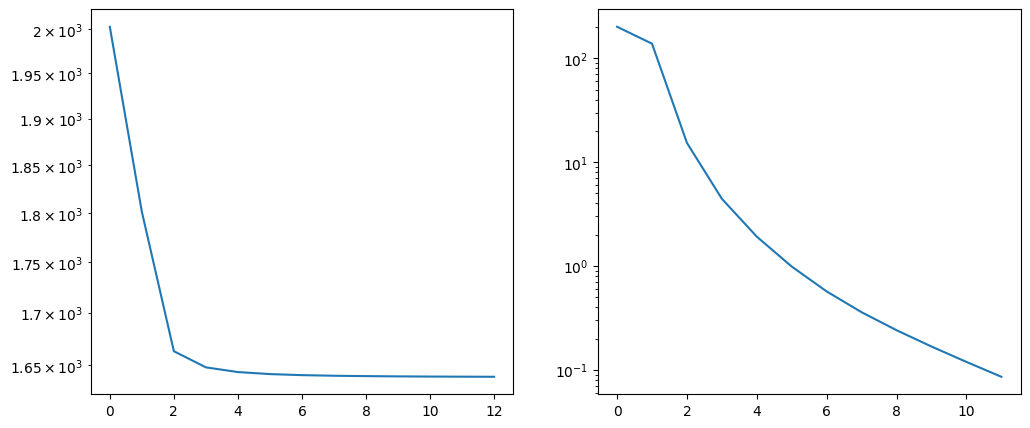

In [12]:
rank = 30
U_als, VT_als, fs, deltas, dists = ALS(A_train, rank, 0.1, debug=True)

fig, axs = plt.subplots(figsize=(12, 5), ncols=2)

axs[0].plot(fs)
axs[1].plot(deltas)
axs[0].semilogy()
axs[1].semilogy()

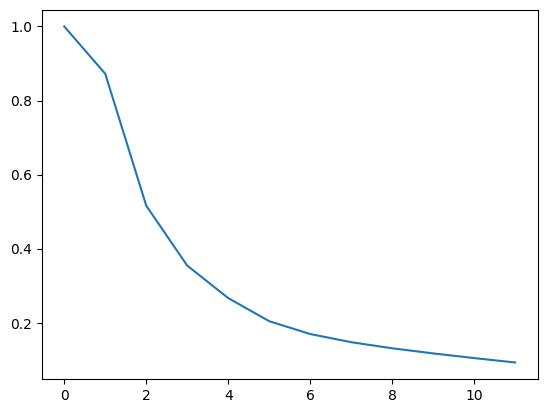

In [13]:
# если выполнили a.3

plt.plot(dists)

### c. (10 баллов) Сравнение с рандомизированным SVD и разреженным SVD

Примените рандомизированное SVD из sklearn, а также SVD из scipy, поддерживающее разреженные матрицы (используйте тот же ранг 30, что и для ALS). Сравните все три результата по значению функционала.

In [14]:
from sklearn.utils.extmath import randomized_svd
from scipy.sparse.linalg import svds

print("ALS error: ", fs[-1])

A_norm = sparse_norm(A_train)

U1, Sigma1, VT1 = randomized_svd(A_train, n_components=rank)
err_rnd = als_functional(A_train, A_norm, U1, np.diag(Sigma1) @ VT1)
print("Randomized SVD error: ", err_rnd)

U2, Sigma2, VT2 = svds(A_train, k=rank)
err_sparse = als_functional(A_train, A_norm, U2, np.diag(Sigma2) @ VT2)
print("Sparce SVD error: ", err_sparse)

ALS error:  1638.9837597335807
Randomized SVD error:  1638.7642
Sparce SVD error:  1638.6792


## d. (25 баллов) Построение рекомендаций
  1. **(10 баллов)** Научимся рекомендовать пользователям из тестовой группы фильмы на основе части их оценок. Напишем функцию `recommend`, которая будет принимать матрицу $V^\top$ из нашей модели, матрицу `(user_id, movie_id) -> binary rating` (то есть того же формата, что и наша основная матрица `A`), а также число `n_recs` &mdash; количество фильмов, которые мы хотим порекомендовать. Возвращать функция будет top-`n_recs` рекомендаций, то есть `n_recs` фильмов, которые могут пользователю понравиться, в порядке убывания предсказанной привлекательности.

  Чтобы построить рекомендацию, необходимо ортогонально спроецировать вектор, соответствующий новому пользователю (про которого мы знаем часть оценок), на пространство $L$, образуемое строками матрицы $V^\top$. Иными словами, мы должны взять ближайший вектор из $L$. Он будет содержать предсказанные нашей моделью рейтинги. Дальше дело техники :) Но не забудьте, что `known_ratings` содержит векторы, соответствующие не одному пользователю, а батчу из `batch_size` пользователей. Хотя и (слава numpy) код остаётся почти дословно такой же.  **Подсказка:** используйте функцию `np.argsort`.

In [15]:
def recommend(VT, known_ratings, n_recs):
    """
        Input
            VT: 2D numpy array
            known_rating: sparse batch_size x n_movies array
            n_recs: requested number of recommendations

        Output
            recs: batch_size x n_recs array of movies to recommend, with descending predicted rating
    """
    Q, _ = np.linalg.qr(VT.T)
    res = known_ratings @ Q @ Q.T

    '''rows, cols = known_ratings.nonzero()
    res[rows, cols] = -np.inf'''

    ind = np.argsort(res, axis=1)
    top_rec = ind[:, -n_recs:][:, ::-1]

    return top_rec

Для проверки нашей модели для каждого пользователя из тестовой выборки оценим так называемый **hit rate**. Для этого выбросим одну из его оценок, вызовем функцию `recommend` и посмотрим, попал ли выкинутый фильм в подборку. Если попал &mdash; это hit, иначе не hit. Для того, чтобы эффективно проделать этот эксперимент на всех тестовых данных, сделаем следующее: разобьём тестовую матрицу на батчи по 500 пользователей и будем предсказывать сразу для целого батча. Вычислим вектор размера `n_test`, где для каждого пользователя указано, на каком месте в рекомендованной подборке оказался скрытый фильм (или число `n_recs`, если скрытого фильма не нашлось среди top-n  рекомендаций).

In [16]:
from scipy.sparse import find

def evaluate_model(VT, A_test, n_recs, batch_size=500):
    """
        Input
            VT: 2D numpy array representing the rating model
            A_test: sparse n_test x n_movies array corresponding to new users
            n_recs: requested number of recommendations
            batch_size: number of users to build recommendations for in a single call to recommend

        Output
            hit_idx: list of n_test ints: place of secret movie
                     in top-n_recs recommendations (or n_recs if it is missing)
    """
    secrets = []
    nonempty_users = []
    A_test = A_test.copy()
    for user in range(A_test.shape[0]):
        _, good, _ = find(A_test[user,:])
        if len(good) == 0:
            continue
        nonempty_users.append(user)
        secret = np.random.choice(good, 1)[0]
        A_test[user, secret] = 0
        secrets.append(secret)
    hit_idx = []
    for i in range(0, len(nonempty_users), batch_size):
        # Build recomendations for a batch.
        recommendations = recommend(VT, A_test[nonempty_users[i:i + batch_size], :], n_recs + 1)
        # Place secret in the last column so that the following .argmax finds it.
        recommendations[:,-1] = secrets[i: i + batch_size]
        # Find secret among the recommendations and place its index into batch_hit_idx.
        batch_hit_idx = (recommendations == np.array([secrets[i:i + batch_size]]).T).argmax(1)
        hit_idx += batch_hit_idx.tolist()
    return hit_idx

  2. **(15 баллов)** Научимся вычислять hit rate для данной модели и заданного количества top-n рекомендаций. Для этого напишем функцию `get_hit_rates`, которая будет принимать $V^\top$ из нашей модели, вектора оценок для новых пользователей `A_test` и список натуральных чисел `n_recs`. Для каждого из этих чисел необходимо посчитать средний hit rate по всем пользователям из `A_test`, то есть, например, для `n_recs == [5, 10, 20]` нужно вернуть список средних хитрейтов для top-5, top-10 и top-20. **Обратите внимание:** вызвать функцию `evaluate_model` нужно только один раз.

In [17]:
def get_hit_rates(VT, A_test, n_recs):
    """
        Input
            VT: 2D numpy array representing the rating model
            A_test: sparse n_test x n_movies array corresponding to new users
            n_recs: list of ints: number of top recomendations to evaluate hit rate for
        Output
            hit_rates: list of float: hit rate for each element of n_recs

    """
    positions = np.array(evaluate_model(VT, A_test, n_recs[-1]))
    n = positions.shape[0]
    hit_rates = []
    for n_rec in n_recs:
        hit_rates.append(np.sum(positions < n_rec) / n)

    return hit_rates

Проверьте себя: вычислите хитрейт на top-10 рекомендаций для Sparse SVD ранга 30. Чтобы вычисления рекомендаций были побыстрее, используйте не всю матрицу `A_test`, а, например, первые 1000 строк. Хитрейт должен получится в районе 12-15%. Самое время подебажить своё решение, если числа сильно расходятся.

In [21]:
print(get_hit_rates(np.diag(Sigma2) @ VT2, A_test[:1000, :], [10]))

[np.float64(0.12384851586489252)]


В чате пишут, что норм рекомендовать то, что уже смотрел человек. Иначе хитрейт подлетает до 0.25

Теперь можно построить графики зависимости hit rate от количества рекомендаций, а также от ранга модели. Сравним результаты, которые дают три алгоритма: ALS, Sparse SVD и рандомизированный SVD.

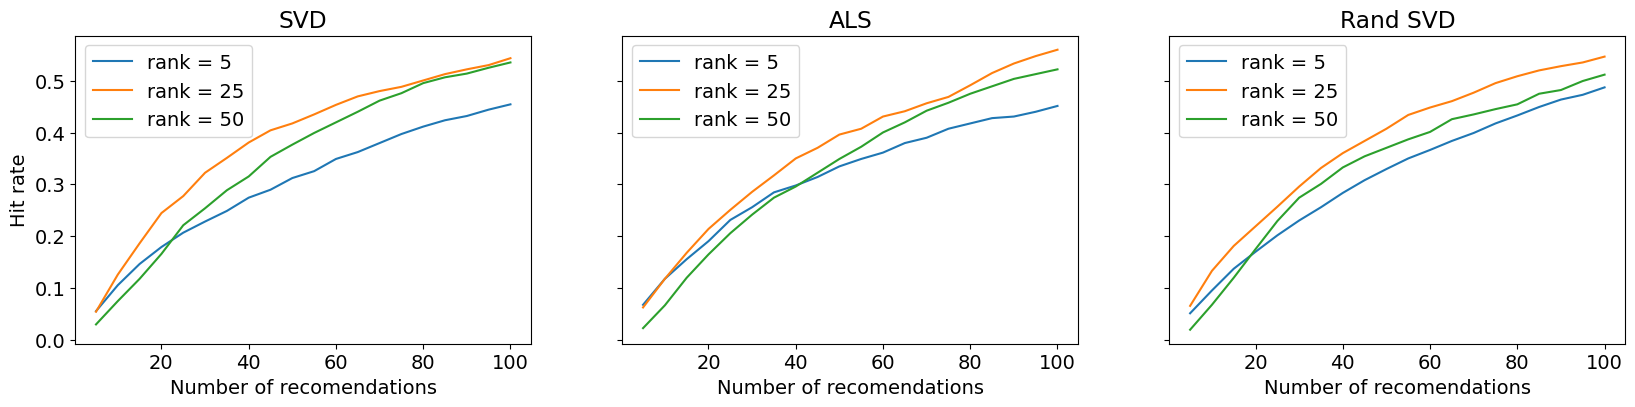

In [22]:
from scipy.sparse.linalg import svds

n_recs = list(range(5, 101, 5))

plt.rcParams.update({'font.size': 14})
_, (ax_svd, ax_als, ax_rand) = plt.subplots(1,3,figsize=(20, 4),sharey=True)

ax_svd.set_title("SVD")
ax_svd.set_ylabel("Hit rate")
ax_als.set_title("ALS")
ax_rand.set_title("Rand SVD")
for rank in [5, 25, 50]:
    _, _, VT_svd = svds(A_train, k=rank)
    _, VT_als, _, _, _ = ALS(A_train, rank)
    _, _, VT_rand = randomized_svd(A_train, rank)
    for VT, ax in zip([VT_svd, VT_als, VT_rand], [ax_svd, ax_als, ax_rand]):
        ax.set_xlabel("Number of recomendations")
        hit_rates = get_hit_rates(VT, A_test[:1000,:], n_recs)
        line, = ax.plot(n_recs, hit_rates)
        line.set_label('rank = {}'.format(rank))
        ax.legend()

Какой ранг приближения оказался оптимальным для нашей модели в случае каждого алгоритма?

**YOUR WORDS GO HERE**

Везде при ранге 25

## Бонус. Higher-order SVD (100 баллов)

**В бонусе разрешается использовать циклы только по размерности.**

1. (**20 баллов**) Напишите функцию ```tuck2full(G, Us)```, возвращающую полный тензор размера $n_1\times n_2 \times \ldots \times n_d$ по его разложению Таккера. Предусмотрите, чтобы функция работала и в случае, если в матрицах $U_1,U_2, \ldots, U_d$ строк меньше, чем столбцов. Вместо циклов используйте функцию ```np.einsum```.

In [36]:
def tuck2full(G, Us):
    """
        Input
            G: d-dimensional numpy array - Tucker core of size (r1, r2, ..., rd)
            Us: tuple of 2D numpy arrays - Tucker factors of size (n1, r1), ..., (nd, rd)

        Output
            A: d-dimensional numpy array of the size (n1, n2, ..., nd)
    """
    d = len(Us)
    subs = ''
    for i in range(d):
        subs += chr(97 + i)
    for i in range(d):
        subs += ','
        subs += chr(97 + d + i)
        subs += chr(97 + i)
    subs += '->'
    for i in range(d):
        subs += chr(97 + d + i)
    oper = [G] + list(Us)

    return np.einsum(subs, *oper)

2. (**35 баллов**) Реализуйте higher-order SVD алгоритм для нахождения разложения Таккера данного $d$-мерного массива $A\in\mathbb{R}^{n_1\times \ldots \times n_d}$. Алгоритм должен находить малоранговое приближение $A$ с относительной точностью не хуже $\varepsilon$ во Фробениусовой норме. Функция должна вернуть ядро и факторы Таккера у приближающего тензора. Для получения ядра Таккера будет удобно воспользоваться функцией ```tuck2full```.

In [37]:
def hosvd(A, eps):
    """
        Input
            A: 3D numpy array
            eps: accuracy of Tucker approximation

        Output
            G: d-dimensional numpy array - Tucker core of size (r1, r2, ..., rd)
            Us: tuple of 2D numpy arrays - Tucker factors of size (n1, r1), ..., (nd, rd)
    """
    d = A.ndim
    A_norm = np.linalg.norm(A)
    err = (eps * A_norm) ** 2 / d
    Us = []

    for i in range(d):
        cur = np.moveaxis(A, i, 0).reshape(A.shape[i], -1)
        U, S, _ = np.linalg.svd(cur, full_matrices=False)
        sigmas = S ** 2
        pr = np.cumsum(sigmas[::-1])
        drop_cnt = np.sum(pr <= err)
        rk_i = max(len(S) - drop_cnt, 1)
        Us.append(U[:, :rk_i])

    Us_T = [U.T for U in Us]
    G = tuck2full(A, tuple(Us_T))

    return G, tuple(Us)

3. (**5 баллов**) Примените функцию ```hosvd``` к тензору размера $25 \times 50 \times 75 \times 100$ с элементами
$$
    a_{ijkl} = \frac{1}{i + j + k + l + 1}, \quad i,j,k,l=0,1,...
$$
для малорангового приближения с точностью $10^{-6}$. Массив $A$ соберите с помощью функции ```np.meshgrid```. Напечатайте получившиеся ранги и относительную ошибку полученного малорангового приближения (для этого используйте функцию ```tuck2full```).

In [39]:
i = np.arange(25)
j = np.arange(50)
k = np.arange(75)
l = np.arange(100)

a1, a2, a3, a4 = np.meshgrid(i, j, k, l)
A = 1.0 / (a1 + a2 + a3 + a4 + 1.0)

G, Us = hosvd(A, 1e-6)

print("Ранги: ", G.shape)
A_approx = tuck2full(G, Us)
norm_A = np.linalg.norm(A)
norm_approx = np.linalg.norm(A - A_approx)
print("Относительная ошибка: ", norm_approx / norm_A)

Ранги:  (9, 8, 9, 10)
Относительная ошибка:  5.23459070300247e-07


4. (**15 баллов**) Докажите, что норма Фробениуса приближения HOSVD $A'$ совпадает с её ядром Таккера $G'$:

$$
  \|A'\|_F = \|G'\|_F
$$

**YOUR WORDS GO HERE**

Пусть $A' = [G', U_1, \ldots U_d]$. Тогда $vec(A') = (U_1 \otimes \ldots \otimes U_d)vec(G')$.

$$\|vec(A)\|_2^2 = \|(U_1 \otimes \ldots \otimes U_d)vec(G')\|_2^2 = vec(G')^T(U_1 \otimes \ldots \otimes U_d)^T(U_1 \otimes \ldots \otimes U_d)vec(G') = $$

$$ = vec(G')^T(U_1^T \otimes \ldots \otimes U_d^T)(U_1 \otimes \ldots \otimes U_d)vec(G') = vec(G')^T(U_1^TU_1 \otimes \ldots \otimes U_d^TU_d)vec(G') = $$

$$ = vec(G')^Tvec(G') = \|vec(G')\|_2^2$$

Значит $\|A'\|_F = \|G'\|_F$

5. (**25 баллов**) Для заданного таккеровского разложения напишите функцию вычисления его нормы. Примените ее к разложению тензора размера 10000 x 10000 x 10000 со случайными Таккеровскими факторами и ядром мультилинейного ранга (10, 10, 10).

Покажу корректность вычисления:

Пусть $A = [G, U_1, \ldots, U_d]$. Из лекций мы знаем, что $vec(A) = (U_1 \otimes \ldots \otimes U_d)vec(G)$

Расмотрим SVD $U_i = Q_i\Sigma_iV^T_i = W_iH_i$. Пусть $W_i = Q_i, H_i = \Sigma_iV^T_i$

Тогда
$$(U_1 \otimes \ldots \otimes U_d)vec(G) = (W_1 \otimes \ldots \otimes W_d)(H_1 \otimes \ldots \otimes H_d)vec(G)$$

Возведём норму в квадрат

$$\|(W_1 \otimes \ldots \otimes W_d)(H_1 \otimes \ldots \otimes H_d)vec(G)\|_2^2 = $$

$$ = vec(G)^T(H_1 \otimes \ldots \otimes H_d)^T\underbrace{(W_1 \otimes \ldots \otimes W_d)^T(W_1 \otimes \ldots \otimes W_d)}_{=(I \otimes \ldots \otimes I)}(H_1 \otimes \ldots \otimes H_d)vec(G) = $$

$$= vec(G)^T(H_1 \otimes \ldots \otimes H_d)^T(H_1 \otimes \ldots \otimes H_d)vec(G) = \|(H_1 \otimes \ldots \otimes H_d)vec(G)\|_2^2$$

То есть нам надо посчитать норму $\|[G, H_1, \ldots, H_d]\|_F$

In [40]:
def tuck_norm(G, Us):
    """
        Input
            G: d-dimensional numpy array - Tucker core of size (r1, r2, ..., rd)
            Us: tuple of 2D numpy arrays - Tucker factors of size (n1, r1), ..., (nd, rd)

        Output
            norm: Frobenius norm of A = [G; U1 ... Ud]
    """

    Hs = []

    for U in Us:
        _, Sigm, Vt = np.linalg.svd(U, full_matrices=False)
        Hs.append(np.diag(Sigm) @ Vt)

    return np.linalg.norm(tuck2full(G, tuple(Hs)))

In [41]:
dims = (10000, 10000, 10000)
ranks = (10, 10, 10)

core = np.random.randn(*ranks)
factors = [np.random.randn(n, r) for n, r in zip(dims, ranks)]
norm = tuck_norm(core, factors)

print(f"Норма тензора: {norm}")

Норма тензора: 32289544.670705404
